Shortest Path:
A -> B -> E -> G
Total cost :  8


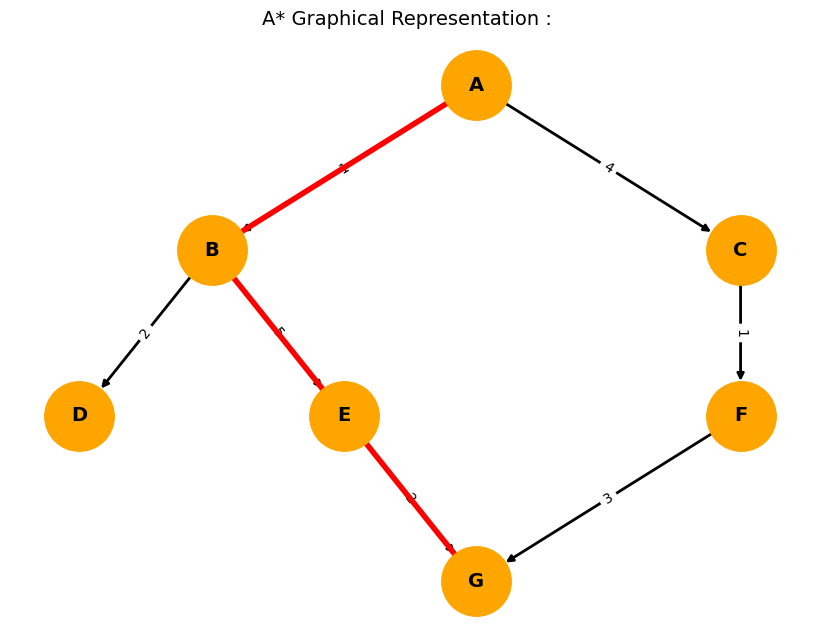

In [34]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'A': [('B', 1), ('C', 4)], 
    'B': [('D', 2), ('E', 5)], 
    'C': [('F', 1)], 
    'D': [], 
    'E': [('G', 2)], 
    'F': [('G', 3)], 
    'G': []
}

heuristic = {'A': 7, 'B': 6, 'C': 2, 'D': 5, 'E': 2, 'F': 1, 'G': 0}

def astar(graph, heuristic, start, goal):
    pq = [(heuristic[start], 0, start, [start])]
    visited = set()
    
    while pq:
        f, g, node, path = heapq.heappop(pq)
        
        if node == goal:
            return path, g
            
        if node in visited:
            continue
        visited.add(node)
        
        for neighbor, cost in graph[node]:
            new_g = g + cost
            new_f = new_g + heuristic[neighbor]
            heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))
            
    return None, float('inf')

path, cost = astar(graph, heuristic, 'A', 'G')

print("Shortest Path:")
print(" -> ".join(path))
print("Total cost : ", cost)


G = nx.DiGraph()

for node in graph :
    for neighbor , weight in graph[node]:
        G.add_edge(node,neighbor, weight = weight)

pos = {
    'A' : (0,3),
    'B' : (-1,2),
    'C' : (1,2),
    'D' : (-1.5,1),
    'E' : (-0.5,1),
    'F' : (1,1),
    'G' : (0,0)
}
plt.figure(figsize =(8,6))
nx.draw (
    G,pos,
    with_labels = True,
    node_color = 'orange',
    node_size = 2500,
    font_size = 14,
    font_weight = 'bold',
    edge_color = 'black',
    arrows = True,
    width=2
)
edge_labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels = edge_labels)
path_edges = list(zip(path[:-1],path[1:]))

nx.draw_networkx_edges(
    G,pos,
    edgelist = path_edges,
    edge_color = 'red',
    width = 4,
    arrows = True
    )
plt.title("A* Graphical Representation : ", fontsize = 14)
plt.axis('off')
plt.show()
           
        
        
        

**AO star**

Optimal Solution Path :
A -> C -> F
Total Cost :  6


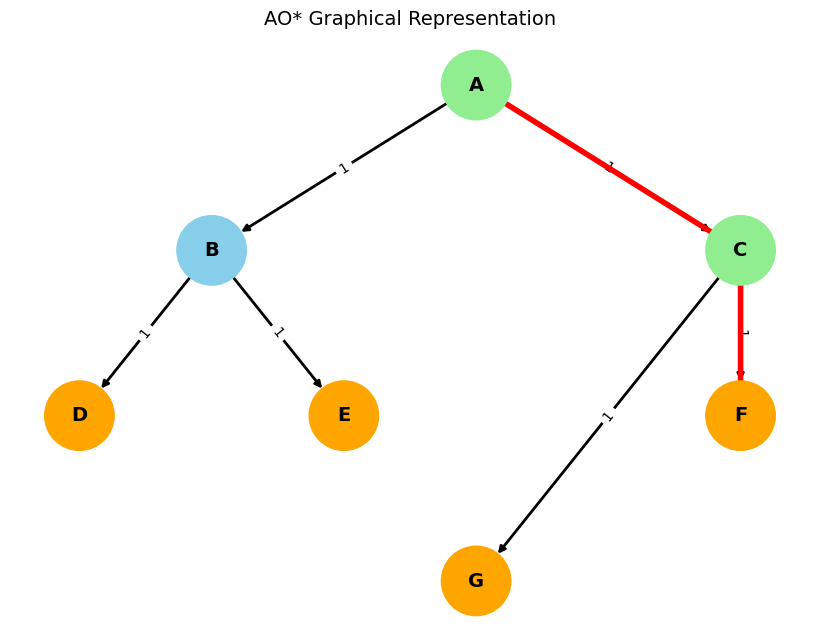

In [42]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'A' : {'type' : "OR", 'Children' : [('B',1), ('C',1)]},
    'B' : {'type' : "AND", 'Children' : [('D',1), ('E',1)]},
    'C' : {'type' : "OR", 'Children' : [('F',1), ('G',1)]},
    'D' : {'type' : "LEAF", 'Cost' : 2},
    'E' : {'type' : "LEAF", 'Cost' : 3},
    'F' : {'type' : "LEAF", 'Cost' : 4},
    'G' : {'type' : "LEAF", 'Cost' : 6}
}

def ao_star(node):
    info = graph[node]
    if info['type'] == 'LEAF':
        return info['Cost'], [node]
    if info['type'] == 'OR':
        best_cost = float('inf')
        best_path = []
        for child, edge_cost in info['Children']:
            child_cost, child_path = ao_star(child)
            total = edge_cost + child_cost
            if total < best_cost:
                best_cost = total
                best_path = [node] + child_path
        return best_cost, best_path
    if info['type'] == 'AND':
        total_cost = 0
        full_path = [node]
        for child, edge_cost in info["Children"]:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path
        return total_cost, full_path

cost, path = ao_star('A')
print("Optimal Solution Path :")
print(" -> ".join(path))
print("Total Cost : ", cost)

G = nx.DiGraph()
for node in graph:
    if 'Children' in graph[node]:
        for neighbor, weight in graph[node]['Children']:
            G.add_edge(node, neighbor, weight=weight)

pos = {
    'A' : (0,3),
    'B' : (-1,2),
    'C' : (1,2),
    'D' : (-1.5,1),
    'E' : (-0.5,1),
    'F' : (1,1),
    'G' : (0,0)
}

node_colors = []
for node in G.nodes():
    node_type = graph[node]['type']
    if node_type == 'AND':
        node_colors.append('skyblue')
    elif node_type == 'OR':
        node_colors.append('lightgreen')
    else:
        node_colors.append('orange')

plt.figure(figsize=(8,6))
nx.draw(
    G, 
    pos, 
    with_labels=True, 
    node_color=node_colors, 
    node_size=2500, 
    font_size=14, 
    font_weight='bold', 
    edge_color='black', 
    arrows=True, 
    width=2
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

path_edges = [(path[i], path[i+1]) for i in range(len(path)-1) if G.has_edge(path[i], path[i+1])]
nx.draw_networkx_edges(
    G, 
    pos, 
    edgelist=path_edges, 
    edge_color='red', 
    width=4, 
    arrows=True
)

plt.title("AO* Graphical Representation", fontsize=14)
plt.axis('off')
plt.show()
